# Gradient boosting survival model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn.**

In [86]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/mUC_training_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/mUC_training_df.csv', dtype = dtype_map)
train_df.shape

(10502, 149)

In [3]:
dtype_map = pd.read_csv('../outputs/mUC_test_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/mUC_test_df.csv', dtype = dtype_map)
test_df.shape

(2626, 149)

In [4]:
# See death_data_mUC.ipynb for details on derivation
death_df = pd.read_csv('../outputs/mUC_death_data.csv')
death_df.shape

(13129, 6)

In [5]:
train_df = pd.merge(train_df, death_df[['PatientID', 'event', 'duration']], on = 'PatientID', how = 'left')
train_df = train_df.query('duration >= 0')
train_df.shape

(10416, 151)

In [6]:
test_df = pd.merge(test_df, death_df[['PatientID', 'event', 'duration']], on = 'PatientID', how = 'left')
test_df = test_df.query('duration >= 0')
test_df.shape

(2601, 151)

## Preprocess

### Selecting features

#### Categorical variables

In [7]:
list(train_df.select_dtypes(include = ['category']).columns)

['Ethnicity_mod',
 'Race_mod',
 'region',
 'PrimarySite',
 'DiseaseGrade',
 'GroupStage_mod',
 'TStage_mod',
 'NStage_mod',
 'MStage_mod',
 'SurgeryType_mod',
 'adv_diagnosis_year',
 'PDL1_status',
 'FGFR_status',
 'ecog_index']

In [8]:
train_df.FGFR_status.value_counts(normalize = True)

FGFR_status
unknown     0.977727
negative    0.015649
positive    0.006624
Name: proportion, dtype: float64

In [9]:
train_df.PDL1_status.value_counts(normalize = True)

PDL1_status
unknown     0.983007
negative    0.012193
positive    0.004800
Name: proportion, dtype: float64

In [10]:
categorical_var = [
    'PrimarySite',
    'DiseaseGrade',
    'GroupStage_mod',
    'SurgeryType_mod',
    'ecog_index'
]

#### Binary variables 

In [11]:
list(train_df.select_dtypes(include = ['int']).columns)

['age',
 'sex_male',
 'SmokingStatus',
 'Surgery',
 'ecog_newly_gte2',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'other_gi_met',
 'other_combined_met',
 'event']

In [12]:
bin_list = [
     'sex_male',
     'SmokingStatus',
     'Surgery',
     'ecog_newly_gte2',
     'hypotension',
     'tachycardia',
     'fevers',
     'hypoxemia',
     'anticoagulant',
     'opioid',
     'steroid',
     'antibiotic',
     'diabetic_med',
     'antidepressant',
     'bone_therapy_agent',
     'immunosuppressant',
     'chf',
     'cardiac_arrhythmias',
     'valvular_disease',
     'pulm_circulation',
     'pvd',
     'htn_uncomplicated',
     'htn_complicated',
     'paralysis',
     'other_neuro',
     'chronic_pulm_disease',
     'diabetes_uncomplicated',
     'diabetes_complicated',
     'hypothyroid',
     'renal_failure',
     'liver_disease',
     'pud',
     'aids_hiv',
     'lymphoma',
     'rheumatic',
     'coagulopathy',
     'obesity',
     'weight_loss',
     'fluid',
     'blood_loss_anemia',
     'deficiency_anemia',
     'alcohol_abuse',
     'drug_abuse',
     'psychoses',
     'depression',
     'lymph_met',
     'thoracic_met',
     'liver_met',
     'bone_met',
     'other_gi_met',
     'other_combined_met']

In [13]:
# Identify binary variables with >3% prevalence 
x_list = []
for x in bin_list:
    if (train_df[x].value_counts(normalize = True)[1] >= 0.03):
        x_list.append(x)

In [14]:
x_list

['sex_male',
 'SmokingStatus',
 'Surgery',
 'hypotension',
 'tachycardia',
 'hypoxemia',
 'opioid',
 'antibiotic',
 'cardiac_arrhythmias',
 'pvd',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'weight_loss',
 'fluid',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'other_combined_met']

In [15]:
# Added ecog_newly_gte2 since likely to be highly predictive
binary_var = [
    'sex_male',
    'SmokingStatus',
    'Surgery',
    'ecog_newly_gte2',
    'hypotension',
    'tachycardia',
    'hypoxemia',
    'opioid',
    'antibiotic',
    'cardiac_arrhythmias',
    'pvd',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'weight_loss',
    'fluid',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'other_combined_met'
]

#### Numerical variables

In [16]:
list(train_df.select_dtypes(include = ['float64']).columns)

['days_diagnosis_to_adv',
 'days_diagnosis_to_surgery',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'chloride',
 'creatinine',
 'hemoglobin',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'chloride_std',
 'creatinine_std',
 'hemoglobin_std',
 'platelet_std',
 'potassium_std',
 'sodium_std',
 'total_bilirubin_s

In [17]:
# Add age and van_walraven_score here even though not float 
numerical_var = [
     'age',
     'van_walraven_score',
     'days_diagnosis_to_adv',
     'days_diagnosis_to_surgery',
     'weight_index',
     'bmi_index',
     'percent_change_weight',
     'albumin',
     'alp',
     'alt',
     'ast',
     'bicarbonate',
     'bun',
     'calcium',
     'chloride',
     'creatinine',
     'hemoglobin',
     'platelet',
     'potassium',
     'sodium',
     'total_bilirubin',
     'wbc',
     'alp_max',
     'ast_max',
     'bicarbonate_max',
     'calcium_max',
     'creatinine_max',
     'hemoglobin_max',
     'platelet_max',
     'potassium_max',
     'sodium_max',
     'total_bilirubin_max',
     'wbc_max',
     'albumin_min',
     'bicarbonate_min',
     'calcium_min',
     'hemoglobin_min',
     'platelet_min',
     'potassium_min',
     'sodium_min',
     'wbc_min'
]

In [18]:
all_var = categorical_var + binary_var + numerical_var

In [19]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       6145
albumin                  6098
total_bilirubin          5943
alt                      5923
chloride                 5899
alp                      5896
ast                      5890
albumin_min              5875
percent_change_weight    5826
total_bilirubin_max      5707
alp_max                  5658
bicarbonate              5656
ast_max                  5655
calcium                  5654
potassium                5637
sodium                   5634
bun                      5603
creatinine               5546
calcium_max              5446
calcium_min              5446
bicarbonate_min          5441
bicarbonate_max          5441
potassium_min            5423
potassium_max            5423
sodium_min               5419
sodium_max               5419
wbc                      5386
hemoglobin               5375
platelet                 5367
creatinine_max           5336
wbc_min                  5178
wbc_max                  5178
hemoglobin_min           5166
hemoglobin

In [20]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [21]:
# Add missing flags to binary_var
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [22]:
all_var = categorical_var + binary_var + numerical_var

In [23]:
len(all_var)

111

### Creating validation set

In [24]:
enh = pd.read_csv('../data/Enhanced_AdvUrothelial.csv')

In [25]:
train_df = pd.merge(train_df, enh[['PatientID', 'AdvancedDiagnosisDate']], on = 'PatientID', how = 'left')

In [26]:
train_df.shape

(10416, 190)

In [27]:
train_df['AdvancedDiagnosisDate'] = pd.to_datetime(train_df['AdvancedDiagnosisDate'])

In [28]:
train_df['adv_year_cat'] = pd.cut(train_df['AdvancedDiagnosisDate'].dt.year,
                                  bins = [2010.5, 2015.5, 2019.5, 2023.5],
                                  labels = ['11-15', '16-19', '20-23'],
                                  include_lowest = True)

In [29]:
# Split into training and validation sets
sub_train_df, val_df = train_test_split(
    train_df,
    test_size = 0.2,
    stratify = train_df['adv_year_cat'], 
    random_state = 42
)

In [30]:
sub_train_df.shape

(8332, 191)

In [31]:
val_df.shape

(2084, 191)

### Splitting into X and Y

In [32]:
y_dtype = [('event', bool), ('duration', float)]

In [33]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

sub_train_y = np.array([tuple(x) for x in sub_train_df[['event', 'duration']].values],
                       dtype = y_dtype)

val_y = np.array([tuple(x) for x in val_df[['event', 'duration']].values],
                 dtype = y_dtype)

### Creating pipeline

In [34]:
# Define preprocessors
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numerical_var),
        ('cat', categorical_pipeline, categorical_var),
        ('pass', 'passthrough', binary_var)],
    remainder = 'drop'
)

## Train model

### Determining number of trees

In [35]:
death_df.duration.median()

np.float64(307.0)

In [36]:
# Gradient Boosting Model
gbm = GradientBoostingSurvivalAnalysis(
    learning_rate = 0.05,
    max_depth = 3,
    subsample = 0.75,
    warm_start = True,
    verbose = 0,
    random_state=42
)

# Build a full pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gbm)
])

# Initialize
max_yr_auc = 0
error_going_up = 0
best_n_estimators = 0
auc_per_tree = []

# Initial fit
full_pipeline.named_steps['model'].n_estimators = 1
full_pipeline.fit(sub_train_df[all_var], sub_train_y)

# Fit an additional 10 trees each round; stop once reach 1000 or validation goes down 5 times 
for n_estimators in range(10, 1000, 10):
    full_pipeline.named_steps['model'].n_estimators = n_estimators
    full_pipeline.fit(sub_train_df[all_var], sub_train_y) 

    gbm_chf_funcs = full_pipeline.predict_cumulative_hazard_function(val_df[all_var])
    gbm_risk_scores = np.array([chf(365) for chf in gbm_chf_funcs])
    gbm_yr_auc = cumulative_dynamic_auc(sub_train_y, val_y, gbm_risk_scores, 365)[0][0]
    auc_per_tree.append(gbm_yr_auc) 
    
    if gbm_yr_auc > max_yr_auc:
        max_yr_auc = gbm_yr_auc
        best_n_estimators = n_estimators
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            print(f"Early stopping at {n_estimators} trees. Best AUC={max_yr_auc:.4f} at {best_n_estimators} trees.")
            break

Early stopping at 520 trees. Best AUC=0.7448 at 470 trees.


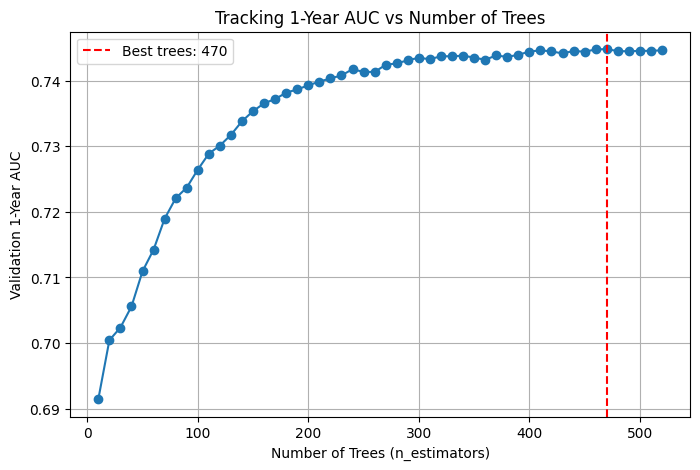

In [37]:
# Plot performance on validations set as trees get added 
plt.figure(figsize=(8, 5))
plt.plot(range(10, 10 * (len(auc_per_tree) + 1), 10), auc_per_tree, marker='o')
plt.axvline(best_n_estimators, color='red', linestyle='--', label=f'Best trees: {best_n_estimators}')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Validation 1-Year AUC")
plt.title("Tracking 1-Year AUC vs Number of Trees")
plt.legend()
plt.grid(True)
plt.show()

### Grid search for hyperparameters

In [38]:
# Gradient Boosting Model
gbm = GradientBoostingSurvivalAnalysis(
    n_estimators = 470,
    learning_rate = 0.05,
    verbose = 0,
    random_state = 42
)

# Build a full pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gbm)
])

# Parameter search 
param_grid = {
    'model__max_depth': [2, 3, 4, 5],
    'model__subsample': [0.6, 0.75, 1.0]
}

# Define a custom scorerer which returns 1-year AUC 
def one_year_auc_scorer(estimator, X, y):
    """Calculate 1-year time-dependent AUC."""
    # Predict cumulative hazard functions
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    
    # Get risk scores at 365 days
    risk_scores = np.array([chf(365) for chf in chf_funcs])
    
    # Calculate cumulative dynamic AUC at 365 days 
    auc = cumulative_dynamic_auc(y, y, risk_scores, 365)[0]
    return auc[0]

# GridSearchCV
grid_search = GridSearchCV(
    estimator = full_pipeline,
    param_grid = param_grid,
    scoring = one_year_auc_scorer,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(train_df[all_var], train_y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'van_walraven_score',
                                                                          'days_diagnosis_to_adv',
                                                                          'days_diagnosis_to_surgery',
                                                                          'weight_index',
                                                                          'bmi_index',
                                                                          'percent_change_weight',
                                                                          'albumin',
                                                                          'alp',
                                                                          'alt',
                                                                          'ast',
                                                                          '...
                                                                          'liver_met',
                                                                          'bone_met',
                                                                          'other_combined_met',
                                                                          'van_walraven_score_na',
                                                                          'weight_index_na',
                                                                          'bmi_index_na', ...])])),
                                       ('model',
                                        GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                                         n_estimators=470,
                                                                         random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [2, 3, 4, 5],
                         'model__subsample': [0.6, 0.75, 1.0]},
             scoring=<function one_year_auc_scorer at 0x287e77ba0>, verbose=1)

In [39]:
best_params = grid_search.best_params_

In [40]:
best_params

{'model__max_depth': 5, 'model__subsample': 0.6}

In [67]:
results_df = pd.DataFrame(grid_search.cv_results_)

In [71]:
results_df.sort_values(by = 'rank_test_score').head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,395.793638,3.193803,0.087568,0.017467,5,0.60,"{'model__max_depth': 5, 'model__subsample': 0.6}",0.725822,0.737971,0.728115,0.753845,0.717722,0.732695,0.012390,1
10,414.136454,2.283015,0.070039,0.007852,5,0.75,"{'model__max_depth': 5, 'model__subsample': 0.75}",0.723615,0.735328,0.727318,0.758167,0.718652,0.732616,0.013887,2
6,408.411342,14.466079,0.083572,0.015397,4,0.60,"{'model__max_depth': 4, 'model__subsample': 0.6}",0.732575,0.731088,0.726195,0.755403,0.716918,0.732436,0.012721,3


## Test model 

### Build final model 

In [41]:
best_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 470,  
    learning_rate = 0.05,
    max_depth = 5,
    subsample = 0.6,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       34029.8921          17.4828            9.23m
         2       34282.0424         283.3809            8.91m
         3       34124.3816        -105.4142            8.80m
         4       34456.4210         357.9044            8.75m
         5       34004.6343        -385.7642            8.72m
         6       33812.9551        -143.5302            8.70m
         7       34372.6447         569.9808            8.68m
         8       33837.6869        -471.1878            8.65m
         9       33994.5868         183.9730            8.63m
        10       34163.1268         191.5193            8.60m
        20       33463.1351        -530.0321            8.34m
        30       33994.7250         271.3127            8.09m
        40       33604.6365         112.3450            7.86m
        50       33718.1621         255.0954            7.65m
        60       33790.4009         206.8206            7.45m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'van_walraven_score',
                                                   'days_diagnosis_to_adv',
                                                   'days_diagnosis_to_surgery',
                                                   'weight_index', 'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium'...
                                                   'liver_disease',
                                                   'coagulopathy',
                                                   'weight_loss', 'fluid',
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'bone_met',
                                                   'other_combined_met',
                                                   'van_walraven_score_na',
                                                   'weight_index_na',
                                                   'bmi_index_na', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=5, n_estimators=470,
                                                  random_state=42,
                                                  subsample=0.6, verbose=1))])

### Evaluate performance on test and training set 

In [42]:
final_chf_funcs = full_pipeline_final.predict_cumulative_hazard_function(test_df[all_var])
final_risk_scores_test = np.array([chf(365) for chf in final_chf_funcs])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 365)[0][0]

print(f"Final 1-Year AUC on Test Set: {final_auc_test:.3f}")

Final 1-Year AUC on Test Set: 0.722


In [43]:
# Bootstrap 1000 1-yr AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        365
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [44]:
final_chf_funcs = full_pipeline_final.predict_cumulative_hazard_function(train_df[all_var])
final_risk_scores_train = np.array([chf(365) for chf in final_chf_funcs])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 365)[0][0]

print(f"Final 1-Year AUC on Train Set: {final_auc_train:.3f}")

Final 1-Year AUC on Train Set: 0.827


In [45]:
# Bootstrap 1000 1-yr AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        365
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [46]:
gbm_auc_1yr_data = {'model': ['gbm'],
                    'auc_1yr_test': final_auc_test,
                    'auc_1yr_test_lower': conf_lower_test,
                    'auc_1yr_test_upper': conf_upper_test,
                    'auc_1yr_train': final_auc_train,
                    'auc_1yr_train_lower': conf_lower_train,
                    'auc_1yr_train_upper': conf_upper_train}
 
gbm_auc_1yr_df = pd.DataFrame(gbm_auc_1yr_data)

In [47]:
gbm_auc_1yr_df

,model,auc_1yr_test,auc_1yr_test_lower,auc_1yr_test_upper,auc_1yr_train,auc_1yr_train_lower,auc_1yr_train_upper
0,gbm,0.722061,0.699402,0.742462,0.827018,0.818362,0.834845


In [48]:
gbm_auc_1yr_df.to_csv('../outputs/gbm_auc_1yr_df.csv', index = False, header = True)

In [49]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

In [50]:
gbm_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
gbm,0.835375,0.792526,0.779858,0.76861,0.761166,0.760631,0.75717,0.747702,0.737157,0.733567,...,0.719944,0.721512,0.725839,0.727141,0.729278,0.727306,0.728063,0.728272,0.727865,0.720823


In [51]:
gbm_auc_over5_df.to_csv('../outputs/gbm_auc_over5_df.csv', index = True, header = True)

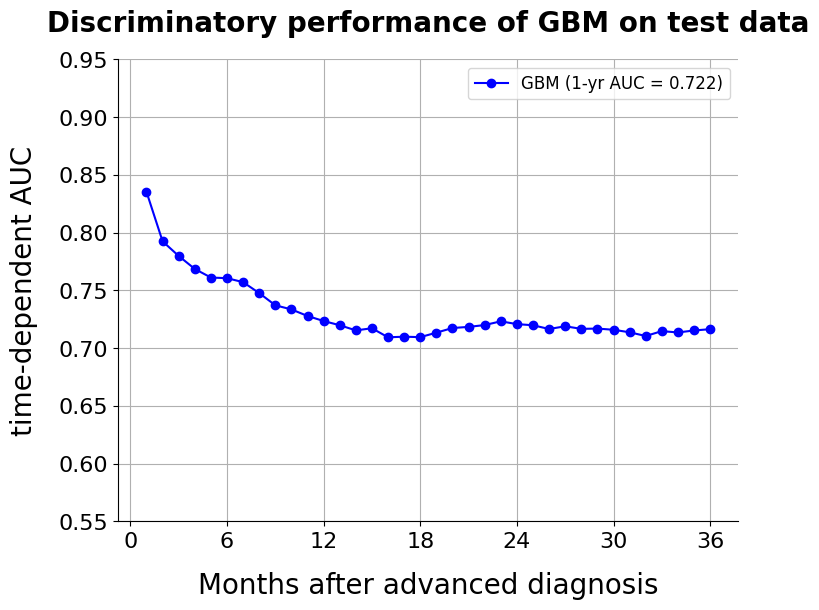

In [52]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (1-yr AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 111
Number of non-zero features in final model: 127


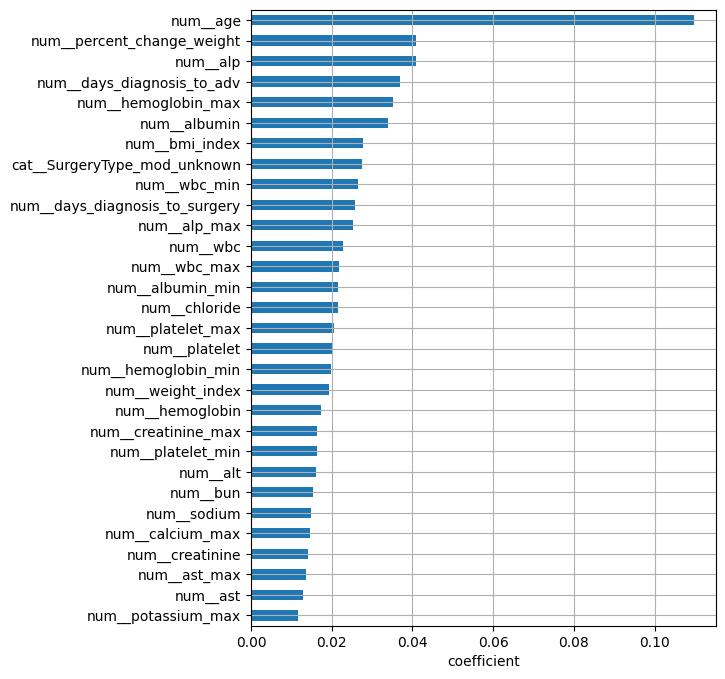

In [53]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [54]:
gbm_feature_importance = (
    gbm_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [55]:
gbm_feature_importance.to_csv('../outputs/gbm_feature_importance.csv', index = False, header = True)

## Calculating risk scores
**Risk scores are calculated for each patient using 5-fold cross-validation. For each fold, a model is trained on 80% of the data, and risk scores are generated for patients in the held-out 20%. This approach ensures that each patient's risk score is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [62]:
df = pd.concat([train_df, test_df])

In [63]:
df.shape

(13017, 191)

In [64]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [66]:
y

array([(False,  120.), ( True,  531.), ( True,  265.), ...,
       ( True,  361.), (False, 2457.), (False, 1545.)],
      shape=(13017,), dtype=[('event', '?'), ('duration', '<f8')])

In [87]:
# Run cross-validation on full dataset
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# For storing indices and predictions
patient_predictions = []

# Get original patients IDs in the order they appear in df
df = df.set_index('PatientID')
all_patient_ids = df.index

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df, df['event'])):
    # Split data
    patient_ids_train =  all_patient_ids[train_idx] 
    patient_ids_test = all_patient_ids[test_idx]
    
    train_df_fold = df.loc[patient_ids_train]
    test_df_fold = df.loc[patient_ids_test]
    
    train_y_fold = y[train_idx]

    model = GradientBoostingSurvivalAnalysis(
        n_estimators = 470,  
        learning_rate = 0.05,
        max_depth = 5,
        subsample = 0.6,
        verbose = 1,
        random_state = 42
    )

    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    full_pipeline.fit(train_df_fold[all_var], train_y_fold)
    
    # Get predictions for test set (ie., hold out set)
    test_predictions = full_pipeline.predict(test_df_fold[all_var])
    
    # Store PatientIDs and their predictions
    fold_predictions = list(zip(patient_ids_test, test_predictions))
    patient_predictions.extend(fold_predictions)

# Add predictions back to original dataframe
pred_dict = dict(patient_predictions)
df['risk_score'] = df.index.map(pred_dict)
df.to_csv('../outputs/risk_score_df_kfold.csv', index = True, header = True)

# Confirm risk scores calculated for all patients 
n_scores = df['risk_score'].notna().sum()
print(f"\nNumber of patients in df: {df.shape[0]}")
print(f"\nNumber of patients with risk scores: {n_scores}")

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       34355.6049          17.4491            9.19m
         2       34533.2640         214.9304            8.97m
         3       34296.8927        -179.8161            8.89m
         4       34041.0042        -204.5123            8.84m
         5       34137.8154         135.6285            8.80m
         6       34132.8516          32.1362            8.78m
         7       34157.9977          64.1490            8.76m
         8       34317.4116         185.2815            8.72m
         9       33926.7097        -336.5848            8.71m
        10       34057.5589         156.7568            8.69m
        20       33785.1287        -566.1995            8.47m
        30       33505.3551        -233.7895            8.23m
        40       33787.3503         236.2915            8.01m
        50       33317.0111        -135.2397            7.79m
        60       33383.8920        -332.9645            7.57m
       